In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv('../data/hr_attrition.csv')

print("Shape:", df.shape)
df.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [3]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [6]:
attrition_rate = (df['Attrition'] == 'Yes').mean() * 100
print(f"Overall attrition rate: {attrition_rate:.1f}%")

Overall attrition rate: 16.1%


In [8]:
overtime_attrition = df.groupby('OverTime')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
print(overtime_attrition)

OverTime
No     10.436433
Yes    30.528846
Name: Attrition, dtype: float64


In [9]:
dept_attrition = df.groupby('Department')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
print(dept_attrition)

Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition, dtype: float64


In [10]:
satisfaction_attrition = df.groupby('JobSatisfaction')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
print(satisfaction_attrition)

JobSatisfaction
1    22.837370
2    16.428571
3    16.515837
4    11.328976
Name: Attrition, dtype: float64


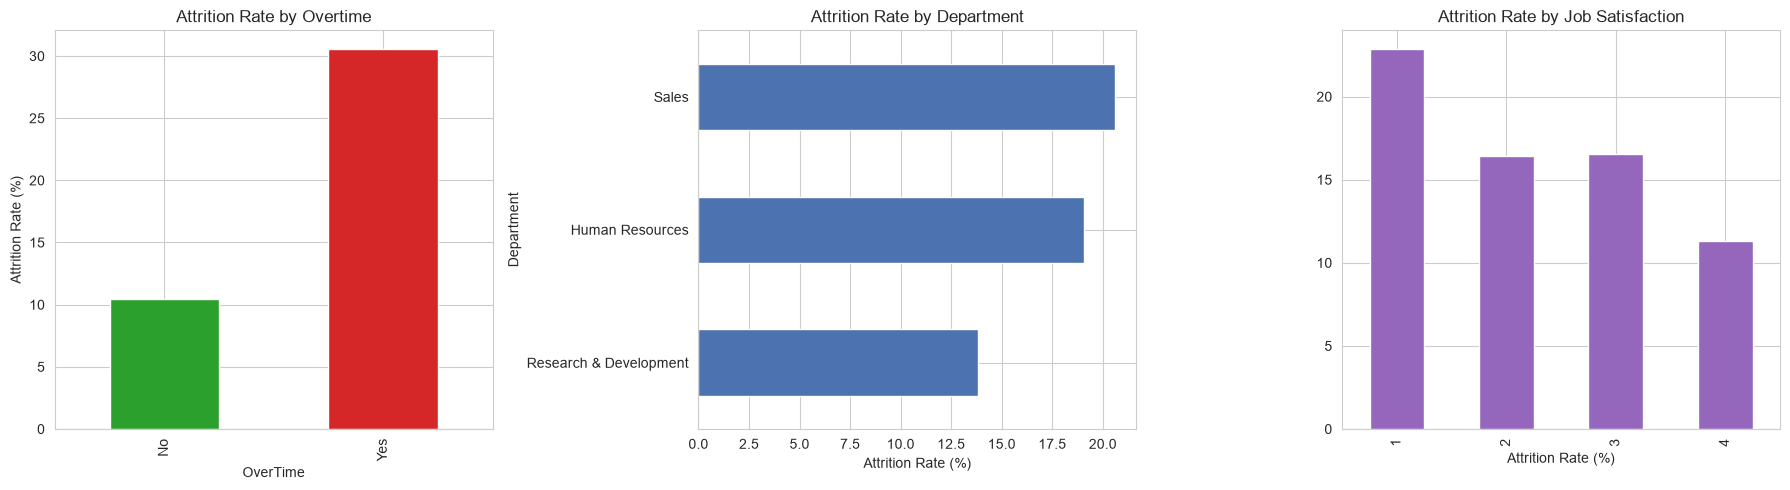

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

overtime_attrition.plot(kind='bar', ax=axes[0], color=['#2ca02c', '#d62728'])
axes[0].set_title('Attrition Rate by Overtime')
axes[0].set_ylabel('Attrition Rate (%)')

dept_attrition.sort_values().plot(kind='barh', ax=axes[1], color='#4C72B0')
axes[1].set_title('Attrition Rate by Department')
axes[1].set_xlabel('Attrition Rate (%)')

satisfaction_attrition.plot(kind='bar', ax=axes[2], color='#9467bd')
axes[2].set_title('Attrition Rate by Job Satisfaction')
axes[2].set_xlabel('Attrition Rate (%)')

plt.tight_layout()
plt.savefig('../images/attrition_by_factor.png', dpi=150)
plt.show()

In [13]:
income_comparison = df.groupby('Attrition')['MonthlyIncome'].describe()
print(income_comparison)

            count         mean          std     min     25%     50%     75%  \
Attrition                                                                     
No         1233.0  6832.739659  4818.208001  1051.0  3211.0  5204.0  8834.0   
Yes         237.0  4787.092827  3640.210367  1009.0  2373.0  3202.0  5916.0   

               max  
Attrition           
No         19999.0  
Yes        19859.0  


In [14]:
tenure_comparison = df.groupby('Attrition')['YearsAtCompany'].describe()
print(tenure_comparison)

            count      mean       std  min  25%  50%   75%   max
Attrition                                                       
No         1233.0  7.369019  6.096298  0.0  3.0  6.0  10.0  37.0
Yes         237.0  5.130802  5.949984  0.0  1.0  3.0   7.0  40.0


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[0], order=['No', 'Yes'] palette=['#2ca02c', '#d62728'])
axes[0].set_title('Monthly Income by Attrition')

sns.boxplot(data=df, x='Attrition', y='YearsAtCompany', ax=axes[1], order=['No', 'Yes'] palette=['#2ca02c', '#d62728'])
axes[1].set_title('Years at Company by Attrition')

plt.tight_layout()
plt.savefig('../images/income_tenure_boxplots.png', dpi=150)
plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (432015798.py, line 3)